# T08 — AR Model (AutoRegressive) — Book: CH05

**Methodology**: Marco Peixeiro, *Time Series Forecasting in Python*, Chapter 5.

### Book-mandated steps:
1. ADF stationarity test on health_index (level + first difference)
2. ACF and PACF plots to visually determine lag order p
3.  — select p by lowest AIC via SARIMAX(order=(p,0,0))
4. Fit best model → Ljung-Box residual test
5.  — walk-forward validation on representative engine
6. Full-dataset prediction → evaluate with RMSE + NASA score

In [16]:
import sys, os
from pathlib import Path

BASE_DIR = Path("/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting")
ROOT = BASE_DIR.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
import sklearn

# Book imports — exactly as CH05 uses them
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from src.models.classical import (
    build_pca_health_index, compute_failure_threshold,
    run_stationarity_report, plot_acf_pacf_multi, smooth_series,
    select_best_ar_order, _get_representative_engine,
    check_residuals, rolling_forecast_engine,
    predict_rul_ar, predict_dataset, RUL_CAP,simulate_test_from_train, validate_model_rolling
)
from src.evaluation.metrics import evaluate

PROC_DIR    = ROOT / "data" / "processed"
SENSOR_COLS = [f"s{i}" for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

## 1. Load data and build health_index

In [18]:
from pathlib import Path

path = Path(PROC_DIR / "train_features.csv")
print(path)
print(path.exists())

/Users/dhruvparmar/DAU/sem_2/IT_402_Applied_Forecasting_Methods/Project/Aircraft Engine Failure Forecasting/data/processed/train_features.csv
True


In [19]:
train = pd.read_csv(PROC_DIR / "train_features.csv")
test  = pd.read_csv(PROC_DIR / "test_features.csv")


train = train[train["engine_id"].isin(train["engine_id"].unique()[:])]
test = test[test["engine_id"].isin(test["engine_id"].unique()[:])]

train, test = build_pca_health_index(train, test, SENSOR_COLS, n_components=2)


THRESHOLD = compute_failure_threshold(train, end_of_life_rul=5, quantile=0.05)
print(f"Failure threshold: {THRESHOLD:.4f}")
print(f"hi_min={train.health_index.min():.3f} | hi_mean={train.health_index.mean():.3f}")

for q in [0.1, 0.2, 0.3, 0.5]:
    t = compute_failure_threshold(train, end_of_life_rul=5, quantile=q)
    hi_min = train["health_index"].min()
    reachable = "✓" if t > hi_min else "✗ below hi_min — forecast will never cross"
    print(f"  quantile={q} → threshold={t:.3f}  hi_min={hi_min:.3f}  {reachable}")

health_index R2 with RUL (post-monotone): -5.188  (target: > 0.3)
Failure threshold: 1.6850
hi_min=-1.597 | hi_mean=-0.000
  quantile=0.1 → threshold=1.747  hi_min=-1.597  ✓
  quantile=0.2 → threshold=1.840  hi_min=-1.597  ✓
  quantile=0.3 → threshold=1.927  hi_min=-1.597  ✓
  quantile=0.5 → threshold=2.166  hi_min=-1.597  ✓


In [20]:
train.shape, test.shape

((61249, 124), (41214, 124))

In [5]:
# In any notebook, after build_pca_health_index
# This tells you EXACTLY what threshold value will work

hi_min  = train["health_index"].min()
hi_max  = train["health_index"].max()
hi_mean = train["health_index"].mean()
print(f"health_index range: [{hi_min:.3f}, {hi_max:.3f}]  mean={hi_mean:.3f}")

# Check what threshold each quantile gives
print("\nThreshold candidates:")
for q in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    t = compute_failure_threshold(train, end_of_life_rul=5, quantile=q)
    # Count test engines whose health_index ever reaches this threshold
    reachable = 0
    for _, g in test.groupby("engine_id"):
        if g["health_index"].max() >= t:
            reachable += 1
    pct = 100 * reachable / test["engine_id"].nunique()
    print(f"  q={q:.2f} → threshold={t:.3f}  |  {reachable}/{test['engine_id'].nunique()} "
          f"test engines reach it ({pct:.0f}%)")

health_index range: [-1.597, 4.402]  mean=-0.000

Threshold candidates:
  q=0.05 → threshold=1.685  |  22/248 test engines reach it (9%)
  q=0.10 → threshold=1.747  |  20/248 test engines reach it (8%)
  q=0.20 → threshold=1.840  |  17/248 test engines reach it (7%)
  q=0.30 → threshold=1.927  |  17/248 test engines reach it (7%)
  q=0.50 → threshold=2.166  |  13/248 test engines reach it (5%)
  q=0.70 → threshold=3.363  |  0/248 test engines reach it (0%)
  q=0.90 → threshold=3.707  |  0/248 test engines reach it (0%)


health_index vs RUL R2: -5.188


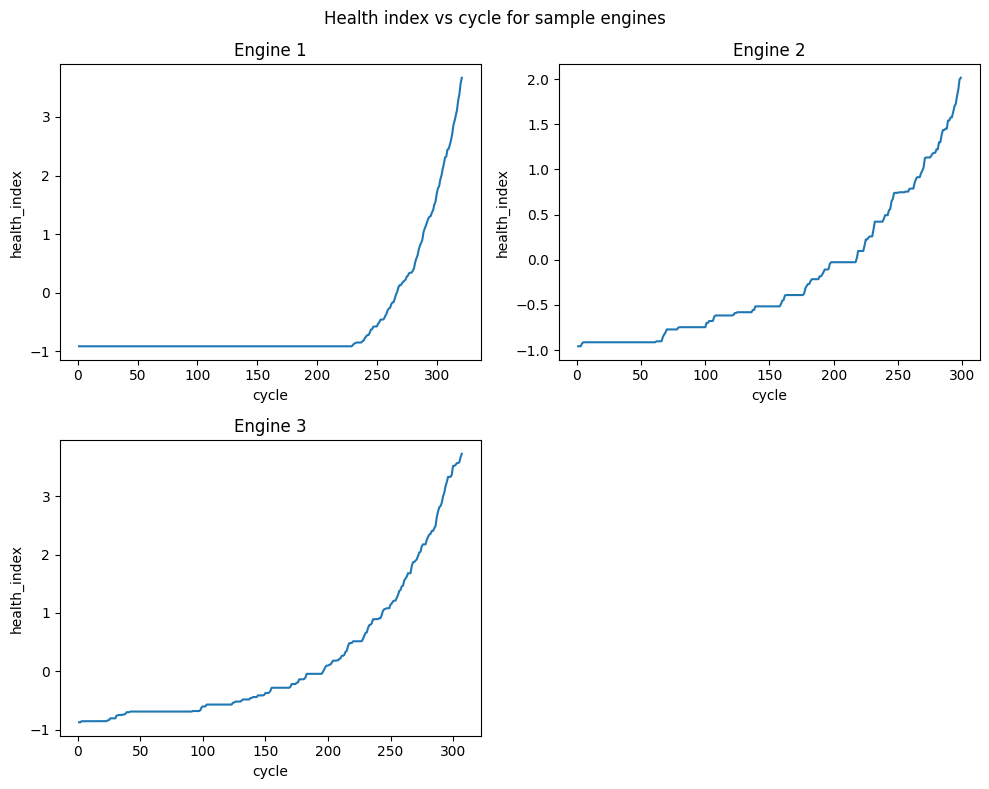

In [6]:
# Sanity check: health_index should increase as RUL decreases
from sklearn.metrics import r2_score
r2 = r2_score(-train["RUL"].values, train["health_index"].values)
print(f"health_index vs RUL R2: {r2:.3f}")
# If R2 < 0.1 → health_index is not tracking degradation → PCA sign flip failed
# If R2 > 0.3 → good signal

# Plot a few engines to visually confirm health_index rises over time
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # makes indexing easier

fig.suptitle("Health index vs cycle for sample engines")

for ax, eid in zip(axes, train["engine_id"].unique()[:3]):  # only 3 plots
    g = train[train["engine_id"] == eid].sort_values("cycle")
    ax.plot(g["cycle"], g["health_index"])
    ax.set_title(f"Engine {eid}")
    ax.set_xlabel("cycle")
    ax.set_ylabel("health_index")

# Hide the 4th (unused) subplot
axes[3].axis("off")

plt.tight_layout()
plt.show()
# Should show rising trend — if flat or noisy → PCA is not capturing degradation

In [7]:
last_rul_per_engine = test.groupby("engine_id")["RUL"].last()
print("True RUL distribution of test engines:")
print(last_rul_per_engine.describe())
print(f"\nEngines with true RUL > 80:  {(last_rul_per_engine > 80).sum()}")
print(f"Engines with true RUL > 100: {(last_rul_per_engine > 100).sum()}")

True RUL distribution of test engines:
count    248.000000
mean      77.858871
std       43.068069
min        6.000000
25%       36.000000
50%       88.000000
75%      125.000000
max      125.000000
Name: RUL, dtype: float64

Engines with true RUL > 80:  135
Engines with true RUL > 100: 100


## 2. Stationarity check — ADF test (CH03 methodology)

Book rule: run ADF at level + first difference. If level p > 0.05 and diff-1 p < 0.05 → d=1.
Here we check a stratified sample across ALL 4 FD subsets, not just 6 engines from FD001.

In [8]:
stationarity_df = run_stationarity_report(train, n_engines=248)
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\nNew MODAL_D = {MODAL_D}")


Stationarity Report (ADF test per sampled engine):
engine_id   level_p     diff1_p     rec_d
--------------------------------------------
1           0.9958      1.0         2.0
2           1.0         0.9267      2.0
3           1.0         0.8719      2.0
4           1.0         0.6973      2.0
5           1.0         1.0         2.0
6           1.0         0.9953      2.0
7           0.9991      0.0007      1.0
8           1.0         0.9014      2.0
9           1.0         0.9697      2.0
10          0.9989      0.9985      2.0
11          1.0         0.0         1.0
12          0.9952      0.9991      2.0
13          1.0         0.0003      1.0
14          0.9951      0.9988      2.0
15          1.0         0.9979      2.0
16          1.0         0.0         1.0
17          1.0         0.9491      2.0
18          1.0         0.9976      2.0
19          1.0         0.0252      1.0
20          1.0         0.0         1.0
21          1.0         0.9928      2.0
22          1.0      


d=0 (already stationary)   : 0 engines
d=1 (1 difference needed)  : 42 engines
d=2 (2 differences needed) : 206 engines

→ Use d = 2 for AR


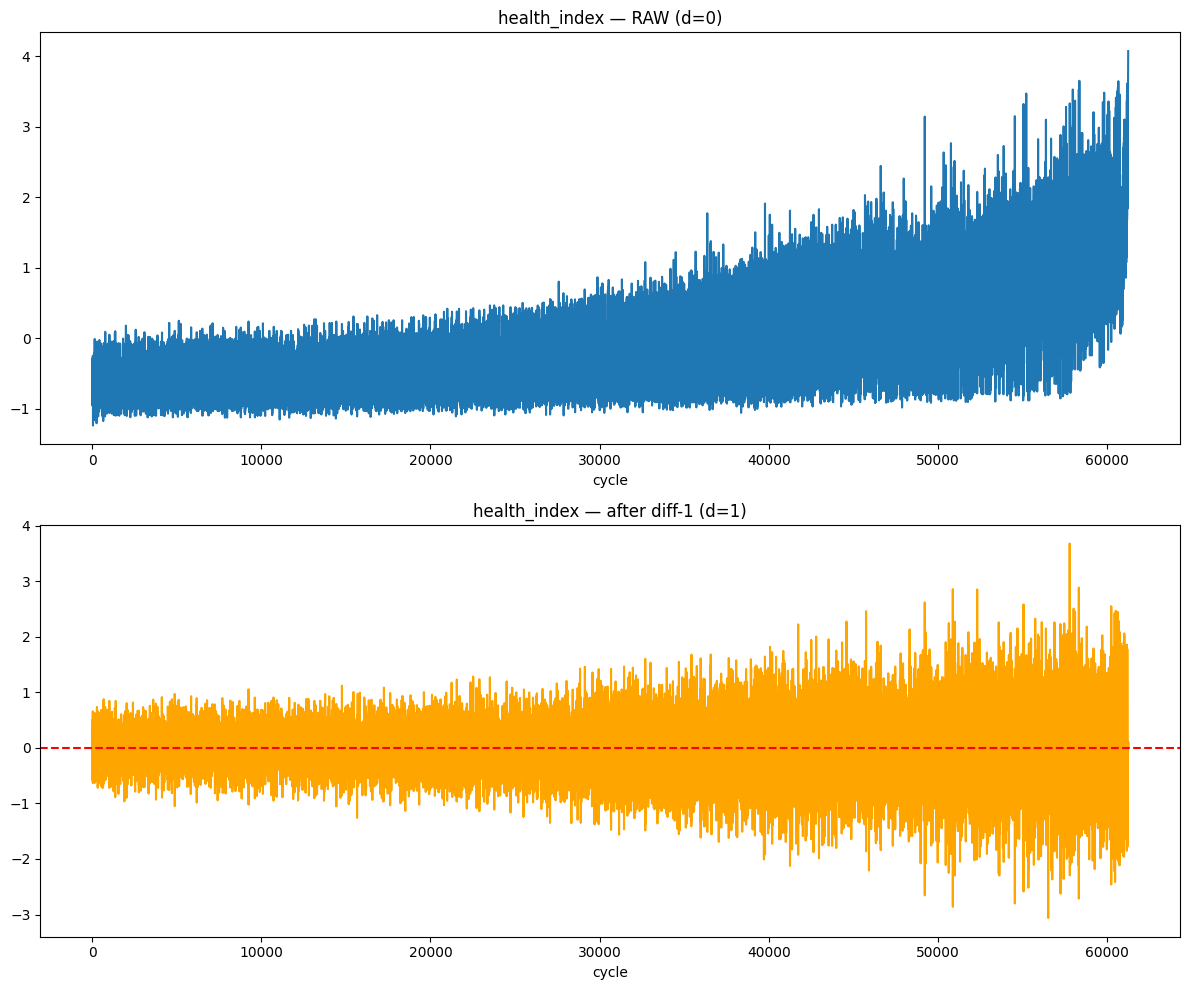

In [9]:
# ── After running stationarity_df = run_stationarity_report(...) ──────

# 1. See d distribution across all engines
d_counts = stationarity_df["recommended_d"].value_counts().sort_index()
print("\nd=0 (already stationary)   :", d_counts.get(0, 0), "engines")
print("d=1 (1 difference needed)  :", d_counts.get(1, 0), "engines")
print("d=2 (2 differences needed) :", d_counts.get(2, 0), "engines")
# 2. Extract the modal d — this is what you pass to ARIMA
MODAL_D = int(stationarity_df["recommended_d"].mode()[0])
print(f"\n→ Use d = {MODAL_D} for AR")

# 3. Visual: compare raw vs differenced for one engine
raw  = train.sort_values("cycle").health_index.values
smth = smooth_series(raw, window=5)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(smth)
axes[0].set_title("health_index — RAW (d=0)")
axes[0].set_xlabel("cycle")

diff1 = np.diff(smth, n=1)
axes[1].plot(diff1, color="orange")
axes[1].axhline(0, color="red", ls="--")
axes[1].set_title("health_index — after diff-1 (d=1)")
axes[1].set_xlabel("cycle")

plt.tight_layout()
plt.show()
# Raw: should show a clear downward trend (non-stationary)
# After diff-1: should hover around 0 with no trend (stationary)

## 3. ACF and PACF plots (CH05 methodology)

Book rule: PACF cuts off at lag p → AR order.
Plot on smoothed health_index (smoothing is applied before fitting in production too).

 length: 61249 cycles


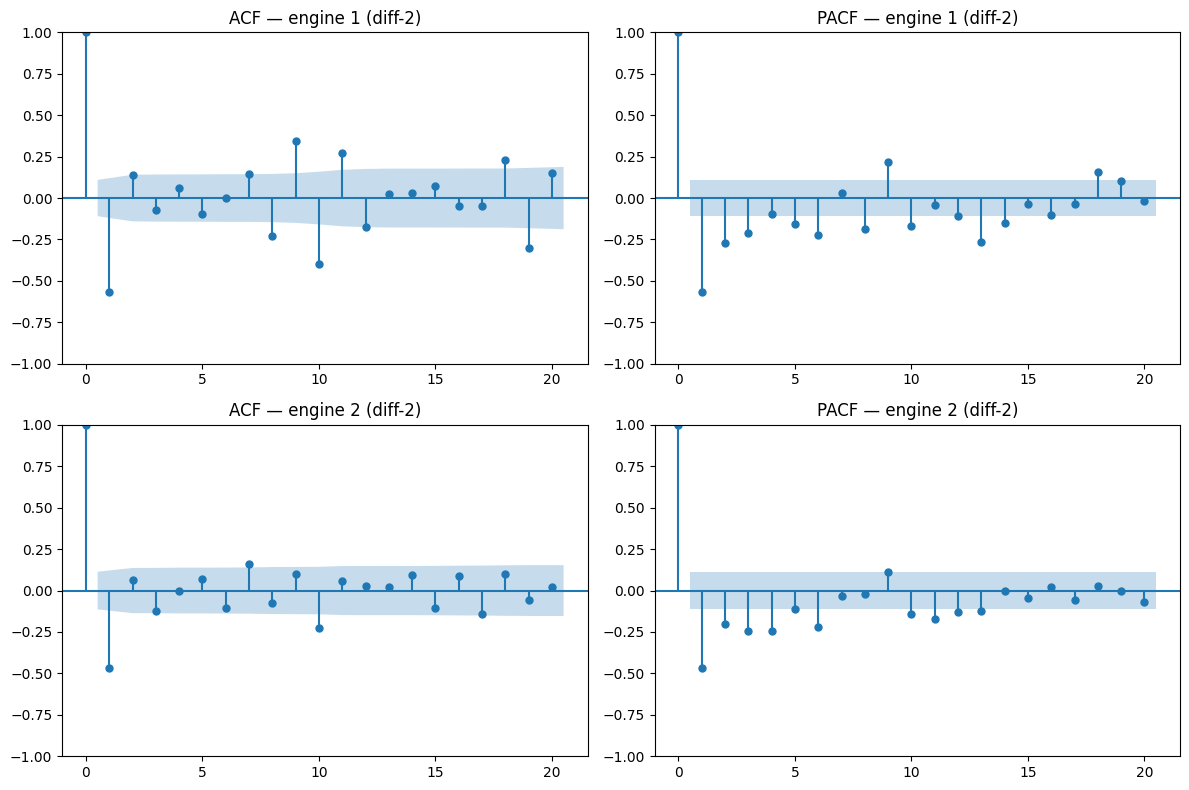

Reading: PACF cuts off at lag p → candidate AR(p)


In [10]:
# Pick one representative engine from FD001 to show ACF/PACF
raw   = train.sort_values("cycle").health_index.values
smth  = smooth_series(raw, window=5)

print(f" length: {len(smth)} cycles")
plot_acf_pacf_multi(train, d=MODAL_D, n_engines=2, lags=20)
print("Reading: PACF cuts off at lag p → candidate AR(p)")

## 4. Optimize AR order by AIC (CH05/CH06 pattern)

Book rule: run optimize function, sort by AIC ascending, pick lowest.

In [11]:
BEST_P = select_best_ar_order(train, d=MODAL_D, n_engines=15)

  engine 1: best p=10  (AIC=-1759.91)
  engine 2: best p=10  (AIC=-1506.21)
  engine 3: best p=10  (AIC=-1481.13)
  engine 4: best p=10  (AIC=-1320.87)
  engine 5: best p=8  (AIC=-908.9)
  engine 6: best p=10  (AIC=-1673.11)
  engine 7: best p=10  (AIC=-1121.43)
  engine 8: best p=9  (AIC=-1137.1)
  engine 9: best p=10  (AIC=-1676.21)
  engine 10: best p=10  (AIC=-1879.24)
  engine 11: best p=7  (AIC=-1567.3)
  engine 12: best p=10  (AIC=-1466.0)
  engine 13: best p=10  (AIC=-1246.39)
  engine 14: best p=10  (AIC=-1239.6)
  engine 15: best p=10  (AIC=-954.93)

→ Modal best AR order: p=10  (from 15 engines, freq=[(10, 12), (8, 1), (9, 1), (7, 1)])


## 5. Fit best AR model and check residuals (Ljung-Box)

Book rule (CH06/CH07): always run Ljung-Box after fitting. All p-values > 0.05 = white-noise residuals = adequate model.

In [12]:
rep_eid, rep_smth = _get_representative_engine(train)
# WHY: no manual diff — SARIMAX handles d internally, matching predict_rul_ar
model_fit = SARIMAX(rep_smth, order=(BEST_P, MODAL_D, 0),
                    simple_differencing=False).fit(disp=False)
print(model_fit.summary())
lb_result = check_residuals(model_fit.resid, model_name=f"AR({BEST_P})")

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  543
Model:              SARIMAX(10, 2, 0)   Log Likelihood                1468.826
Date:                Fri, 24 Apr 2026   AIC                          -2915.653
Time:                        19:27:08   BIC                          -2868.425
Sample:                             0   HQIC                         -2897.184
                                - 543                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8182      0.028    -29.271      0.000      -0.873      -0.763
ar.L2         -0.6387      0.038    -17.005      0.000      -0.712      -0.565
ar.L3         -0.5312      0.042    -12.522      0.0

## 6. Rolling forecast on representative engine (CH05 pattern)

Book rule: walk-forward validation — refit at each window step, predict out-of-sample.

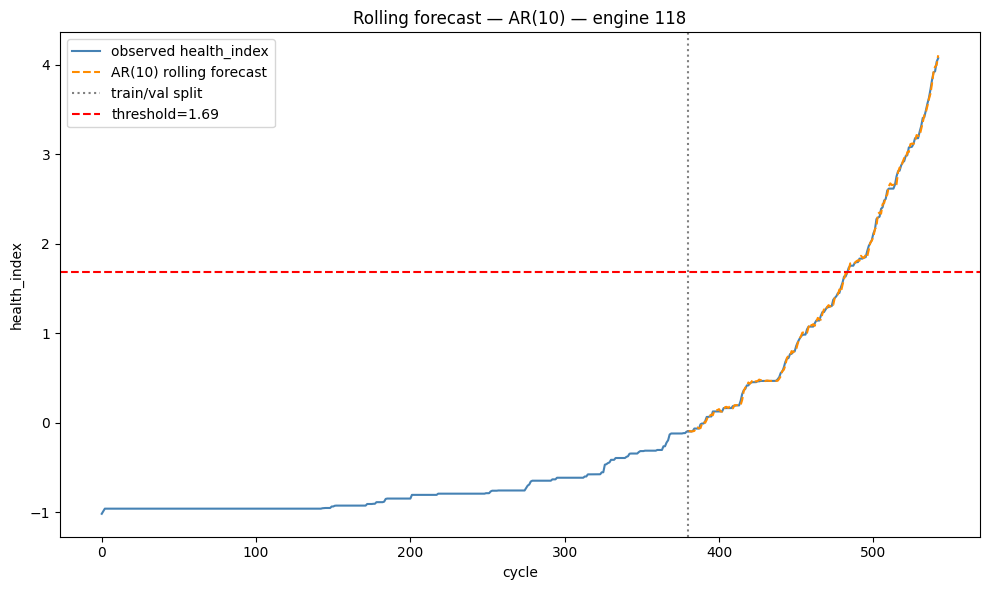

Rolling forecast RMSE: 0.0280


In [13]:
TRAIN_LEN = int(len(rep_smth) * 0.7)   # WHY: model runs on rep_smth, not rep_diff
WINDOW    = 1

pred_ar = rolling_forecast_engine(
    series=rep_smth, train_len=TRAIN_LEN,
    order=(BEST_P, MODAL_D, 0),
    window=WINDOW,
)

# WHY: slice actual from rep_smth — same scale as predictions
actual_val = rep_smth[TRAIN_LEN: TRAIN_LEN + len(pred_ar)]

fig, ax = plt.subplots(figsize=(10, 6))
# WHY: plot rep_smth (original scale), not rep_diff
ax.plot(rep_smth, color="steelblue", label="observed health_index")
ax.plot(range(TRAIN_LEN, TRAIN_LEN + len(pred_ar)), pred_ar,
        color="darkorange", ls="--", label=f"AR({BEST_P}) rolling forecast")
ax.axvline(TRAIN_LEN, color="gray", ls=":", label="train/val split")
ax.axhline(THRESHOLD, color="red", ls="--", label=f"threshold={THRESHOLD:.2f}")
ax.set_xlabel("cycle"); ax.set_ylabel("health_index")
ax.set_title(f"Rolling forecast — AR({BEST_P}) — engine {rep_eid}")
ax.legend(); plt.tight_layout(); plt.show()

# WHY: both actual_val and pred_ar now at same original scale
rmse_roll = float(np.sqrt(np.mean((actual_val - pred_ar)**2)))
print(f"Rolling forecast RMSE: {rmse_roll:.4f}")

## 7. Full test-set evaluation

In [14]:
predict_fn = partial(predict_rul_ar, p=BEST_P, d=MODAL_D)
y_true, y_pred = predict_dataset(test, predict_fn, THRESHOLD, verbose_engines=True)
evaluate(y_true, y_pred, model_name=f"AR({BEST_P})")

    engine    1  true=  22.0  pred=   9.7  err=-12.3
    engine    2  true=  39.0  pred=  15.8  err=-23.2
    engine    3  true= 107.0  pred= 110.0  err=+3.0 [FALLBACK]
    engine    4  true=  75.0  pred= 110.0  err=+35.0 [FALLBACK]
    engine    5  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine    6  true=  78.0  pred= 109.1  err=+31.1
    engine    7  true=  94.0  pred=  67.8  err=-26.2
    engine    8  true=  14.0  pred=   4.4  err=-9.6
    engine    9  true=  99.0  pred= 125.0  err=+26.0
    engine   10  true= 125.0  pred=  74.8  err=-50.2
    engine   11  true= 125.0  pred= 125.0  err=+0.0
    engine   12  true=   7.0  pred=   2.6  err=-4.4
    engine   13  true=  71.0  pred= 125.0  err=+54.0
    engine   14  true= 105.0  pred= 110.0  err=+5.0 [FALLBACK]
    engine   15  true=  12.0  pred=   2.6  err=-9.4
    engine   16  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine   17  true= 125.0  pred= 110.0  err=-15.0 [FALLBACK]
    engine   18  true= 104.0  pred= 125

{'rmse': 27.671329498291016,
 'nasa_score': 25742.193359375,
 'nasa_score_mean': 103.79916677167338,
 'r2_score': 0.5855196118354797,
 'bias': -4.735483646392822}

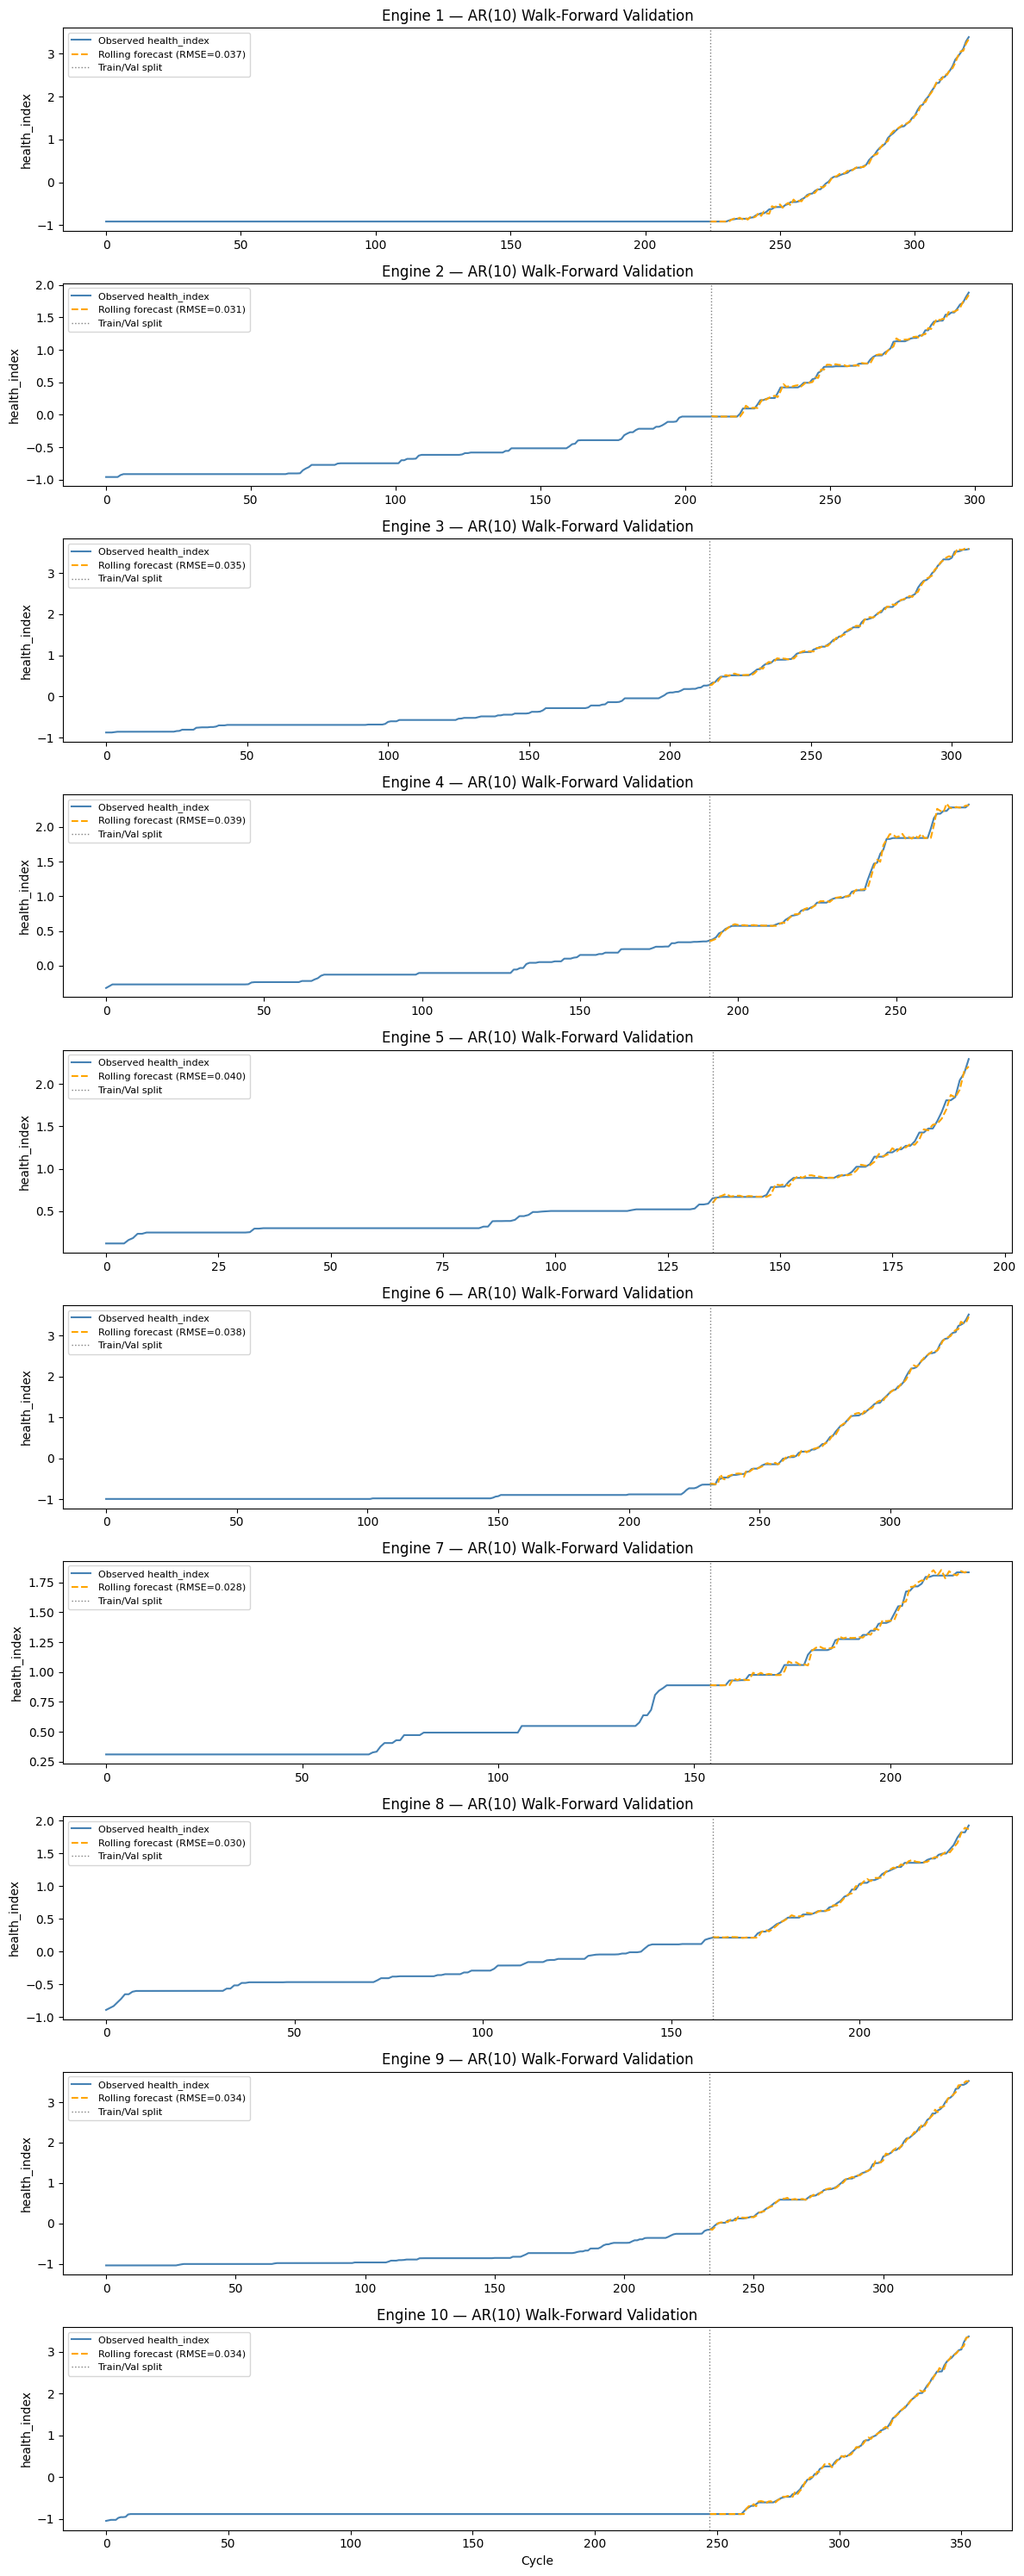


AR(10) Walk-Forward Validation Summary
Engines validated : 10
Mean RMSE         : 0.0346
Std RMSE          : 0.0038
Best engine RMSE  : 0.0279
Worst engine RMSE : 0.0399


In [15]:
val_rmse = validate_model_rolling(
    train      = train,
    order      = (BEST_P, MODAL_D, 0),   # AR: q=0
    n_engines  = 10,
    model_name = f"AR({BEST_P})"
)